In [4]:
import numpy as np
import pandas as pd
df = pd.read_csv(r"D:\DEPI\Data\movies\movies.csv")
df.sample(10)

,id,title,genres,original_language,overview,popularity,production_companies,release_date,budget,revenue,runtime,status,tagline,vote_average,vote_count,credits,keywords,poster_path,backdrop_path,recommendations
91673,100463,Black Cat Mansion,Drama-Horror,ja,The descendant of the servant of a cruel and v...,2.198,Shintoho Company,1958-07-13,0.0,0.0,69.0,Released,NaN,6.8,12.0,Toshio Hosokawa-Yuriko Ejima-Fujie Satsuki-Hir...,samurai-haunted house-revenge-haunting-mansion...,/8avPh20Tz1MdiqcRLz6HdYdt1X6.jpg,/A6wZbjAKd2KED7MX6giQuiAazbR.jpg,NaN
244208,476378,Kevyn Aucoin Beauty & the Beast in Me,Documentary,en,A documentary exploring the life and legacy of...,0.921,NaN,2017-07-07,0.0,0.0,90.0,Released,NaN,7.5,2.0,Kevyn Aucoin-Cindy Crawford-Andie MacDowell-Am...,NaN,/7eLQtBnk0npQ1hw9YRQzDUy6pta.jpg,/e0rBEUIeSeLo7EdPez8XxX68keW.jpg,NaN
286908,201466,Einer spinnt immer,Comedy,de,A comedy directed by Franz Antel.,0.840,Terra-Filmkunst-Neue Delta Filmproduktion,1971-07-30,0.0,0.0,84.0,Released,NaN,0.0,0.0,Georg Thomalla-Teri Tordai-Uwe Friedrichsen-El...,NaN,/sIc4JSIsCTRb80VHrWBzOCtnWee.jpg,NaN,NaN
615172,727518,Year-round Metal Enjoyment,Documentary,en,Year-round Metal Enjoyment explores the New En...,0.600,NaN,2015-10-01,0.0,0.0,95.0,Released,A New England freight train experience,0.0,0.0,NaN,NaN,/iVxIBaUoCQPHAelwrPBiQRoNZzi.jpg,NaN,NaN
559262,890362,The World Next Door,NaN,en,Families are always complicated and Christmas ...,0.600,NaN,2020-11-07,0.0,0.0,10.0,Released,NaN,0.0,0.0,NaN,NaN,/vZMLoBaCMXvE1jRWoxIW3IaRnfo.jpg,NaN,NaN
129157,118641,Overdrawn at the Memory Bank,Romance-Science Fiction-TV Movie,en,Raul Julia plays Aram Fingal a very intelligen...,1.584,Thirteen-RSL-SFTV,1984-09-22,0.0,0.0,83.0,Released,"Caught in a future world, his only escape is b...",2.7,19.0,Raul Julia-Linda Griffiths-Donald Moore-Wanda ...,based on novel or book-virtual reality-compute...,/kGRzs4UbPbZXutXt102YfJh04QY.jpg,NaN,NaN
407887,387677,The Taxi Driver,NaN,en,This short 1954 film from the Faces of Canada ...,0.600,NaN,1954-01-01,0.0,0.0,0.0,Released,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
529983,609543,None of Your Beesiness?,Animation,en,Short animation film by Maria Alves,0.600,Escola das Artes - Universidade Católica,2019-06-14,0.0,0.0,0.0,Released,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
694912,846878,Boney M - Music Video Stars,Music,fr,NaN,0.600,NaN,2013-09-17,0.0,0.0,0.0,Released,NaN,4.0,1.0,NaN,NaN,/kjILgJjGydhWmvmdiaxIpV8pQBf.jpg,NaN,NaN
491774,641620,Xalko,Documentary,ku,A small village in Turkish Anatolia slowly bec...,0.600,NaN,2018-11-15,0.0,0.0,100.0,Released,NaN,0.0,0.0,NaN,NaN,/yzaZwdeGOXoslu69B0awCGQIiNk.jpg,NaN,NaN


In [12]:
import pandas as pd # Python library for data analysis and data frame
import numpy as np # Numerical Python library for linear algebra and computations
pd.set_option('display.max_columns', None) # code to display all columns

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# libraries for text processing
import nltk
from nltk.stem.snowball import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# to display images
from skimage import io

# to save the required files
import pickle

import warnings
warnings.filterwarnings('ignore') # To prevent kernel from showing any warning

In [14]:
df.head()

,id,title,genres,original_language,overview,popularity,production_companies,release_date,budget,revenue,runtime,status,tagline,vote_average,vote_count,credits,keywords,poster_path,backdrop_path,recommendations
0,760161,Orphan: First Kill,Horror-Thriller,en,After escaping from an Estonian psychiatric fa...,8098.027,Dark Castle Entertainment-Entertainment One-Ea...,2022-07-27,0.0,9572765.0,99.0,Released,There's always been something wrong with Esther.,6.963,821.0,Isabelle Fuhrman-Julia Stiles-Rossif Sutherlan...,psychopath-family secrets-prequel-murder-imper...,/wSqAXL1EHVJ3MOnJzMhUngc8gFs.jpg,/5GA3vV1aWWHTSDO5eno8V5zDo8r.jpg,606237-818502-744276-721930-1001925-762504-982...
1,718930,Bullet Train,Action-Comedy-Thriller,en,Unlucky assassin Ladybug is determined to do h...,7949.491,Columbia Pictures-87North Productions,2022-07-03,90000000.0,231398720.0,126.0,Released,The end of the line is just the beginning.,7.497,1238.0,Brad Pitt-Joey King-Aaron Taylor-Johnson-Brian...,japan-assassin-based on novel or book-mission-...,/tVxDe01Zy3kZqaZRNiXFGDICdZk.jpg,/y2Ca1neKke2mGPMaHzlCNDVZqsK.jpg,1002564-762504-755566-1002171-682507-884453-55...
2,744276,After Ever Happy,Romance-Drama,en,As a shocking truth about a couple's families ...,4017.342,Voltage Pictures-Vertical Entertainment-CalMap...,2022-08-24,0.0,0.0,95.0,Released,They can't stop loving each other.,6.830,215.0,Josephine Langford-Hero Fiennes Tiffin-Louise ...,based on novel or book-love-teenage crush,/6b7swg6DLqXCO3XUsMnv6RwDMW2.jpg,/rwgmDkIEv8VjAsWx25ottJrFvpO.jpg,20966-676701-419669-804251-766907-619803-67670...
3,579974,RRR,Action-Drama,te,A fictional history of two legendary revolutio...,3416.323,Lyca Productions-DVV Entertainment-Pen Studios,2022-03-24,69000000.0,160000000.0,182.0,Released,"Rise, roar, revolt.",7.774,370.0,N.T. Rama Rao Jr.-Ram Charan-Alia Bhatt-Ajay D...,revolution-liberation-slavery-freedom fighter-...,/wE0I6efAW4cDDmZQWtwZMOW44EJ.jpg,/i0Y0wP8H6SRgjr6QmuwbtQbS24D.jpg,601337-889741-587412-766116-792358-680058-2372...
4,532639,Pinocchio,Fantasy-Adventure-Family,en,A wooden puppet embarks on a thrilling adventu...,3239.378,Walt Disney Pictures-Depth of Field,2022-09-07,0.0,0.0,105.0,Released,The timeless classic.,6.753,800.0,Benjamin Evan Ainsworth-Tom Hanks-Joseph Gordo...,fairy-musical-puppet-live action and animation...,/g8sclIV4gj1TZqUpnL82hKOTK3B.jpg,/nnUQqlVZeEGuCRx8SaoCU4XVHJN.jpg,985939-610150-760741-921360-576925-616037-5799...


In [16]:
df.shape

(744493, 20)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744493 entries, 0 to 744492
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    744493 non-null  int64  
 1   title                 744487 non-null  object 
 2   genres                523793 non-null  object 
 3   original_language     744493 non-null  object 
 4   overview              623360 non-null  object 
 5   popularity            744493 non-null  float64
 6   production_companies  345206 non-null  object 
 7   release_date          687712 non-null  object 
 8   budget                744493 non-null  float64
 9   revenue               744493 non-null  float64
 10  runtime               706032 non-null  float64
 11  status                744493 non-null  object 
 12  tagline               109984 non-null  object 
 13  vote_average          744493 non-null  float64
 14  vote_count            744493 non-null  float64
 15  

In [20]:
df.isnull().sum()

id                           0
title                        6
genres                  220700
original_language            0
overview                121133
popularity                   0
production_companies    399287
release_date             56781
budget                       0
revenue                      0
runtime                  38461
status                       0
tagline                 634509
vote_average                 0
vote_count                   0
credits                 231329
keywords                529469
poster_path             199099
backdrop_path           519126
recommendations         700806
dtype: int64

In [28]:
df.duplicated().sum()


173

In [30]:
df.duplicated(subset='title').sum()

168588

In [32]:
df.duplicated(subset='id').sum()

82410

In [54]:
df.drop_duplicates(inplace=True)

In [55]:
df.drop_duplicates(subset=['title','release_date'], inplace=True)


In [56]:
df.shape

(659948, 20)

In [60]:
df1=df[df['vote_count']>=20].reset_index()

In [64]:
df1.isnull().sum()

index                       0
id                          0
title                       0
genres                    179
original_language           0
overview                  475
popularity                  0
production_companies     3306
release_date                2
budget                      0
revenue                     0
runtime                    16
status                      0
tagline                 20420
vote_average                0
vote_count                  0
credits                   647
keywords                 9576
poster_path               138
backdrop_path            2436
recommendations         11658
dtype: int64

In [66]:
df1.shape

(43229, 21)

In [70]:
df1.fillna(' ', inplace=True)

In [72]:
index = df1[(df1['genres']==' ') & (df1['overview']==' ')].index

In [74]:
df1.drop(index, inplace=True)

In [76]:
df1.shape

(43194, 21)

In [80]:
df1['genres']=df1['genres'].apply(lambda x: ' '.join(x.split('-')))
df1['kerwords']=df1['keywords'].apply(lambda x: ' '.join(x.split('-')))
df1['credits']=df1['credits'].apply(lambda x: ' '.join(x.replace(' ',' ').split('-')[:5]))

In [84]:
df1['tags']=df1['overview']+' '+ df1['genres']+' '+df1['keywords']+' '+df1['credits']+' '+df1['original_language']

In [86]:
df1.tags[0]

'After escaping from an Estonian psychiatric facility Leena Klammer travels to America by impersonating Esther the missing daughter of a wealthy family. But when her mask starts to slip she is put against a mother who will protect her family from the murderous “child” at any cost. Horror Thriller psychopath-family secrets-prequel-murder-impersonator-mental patient-psycho killer-escaped mental patient-missing daughter-estonia-female psychopath Isabelle Fuhrman Julia Stiles Rossif Sutherland Matthew Finlan Hiro Kanagawa en'

In [93]:
stemmer = SnowballStemmer("english")
def stem(text):
    y = []
    
    for i in text.split():
        y.append(stemmer.stem(i))
        
    return ' '.join(y)

df1['tags'] = df1['tags'].apply(stem)

In [89]:
df1['tags'] = df1['tags'].str.replace('[^\w\s]','')

In [97]:
tfidf = TfidfVectorizer(stop_words='english')

In [99]:
tfidf_matrix= tfidf.fit_transform(df1['tags'])

In [101]:
df1.tags[4]

'a wooden puppet embark on a thrill adventur to becom a real boy. fantasi adventur famili fairy-musical-puppet-l action and animation-l action remake-talk animals-pinocchio benjamin evan ainsworth tom hank joseph gordon levitt luke evan en'

In [103]:
# Function that takes in movie title as input and outputs most similar movies
def get_recommendations(title):
    # Get the index of the movie that matches the title
    idx = df1.index[df1['title'] == title][0]
    # show given movie poster
    try:
        a = io.imread(f'https://image.tmdb.org/t/p/w500/{df1.loc[idx, "poster_path"]}')
        plt.imshow(a)
        plt.axis('off')
        plt.title(title)
        plt.show()
    except:pass
    
    print('Recommendations\n')


    # Get the pairwise similarity scores of all movies with that movie
    sim_scores = list(enumerate(
        cosine_similarity(
            tfidf_matrix,
            tfidf_matrix[idx])))

    # Sort the movies based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the 10 most similar movies
    sim_scores = sim_scores[1:10]

    # Get the movie indices
    movie_indices = [i[0] for i in sim_scores]

    # Return the top 10 most similar movies
    result = df1.iloc[movie_indices]
    
    # show reco. movie posters
    fig, ax = plt.subplots(2, 4, figsize=(15,15))
    ax=ax.flatten()
    for i, j in enumerate(result.poster_path):
        try:
            ax[i].axis('off')
            ax[i].set_title(result.iloc[i].title)
            a = io.imread(f'https://image.tmdb.org/t/p/w500/{j}')
            ax[i].imshow(a)
        except: pass
    fig.tight_layout()
    fig.show()

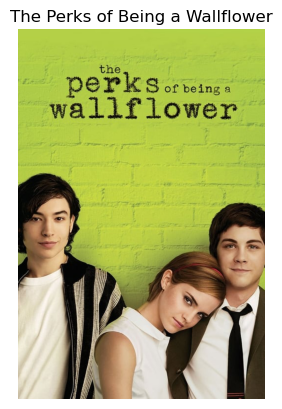

Recommendations



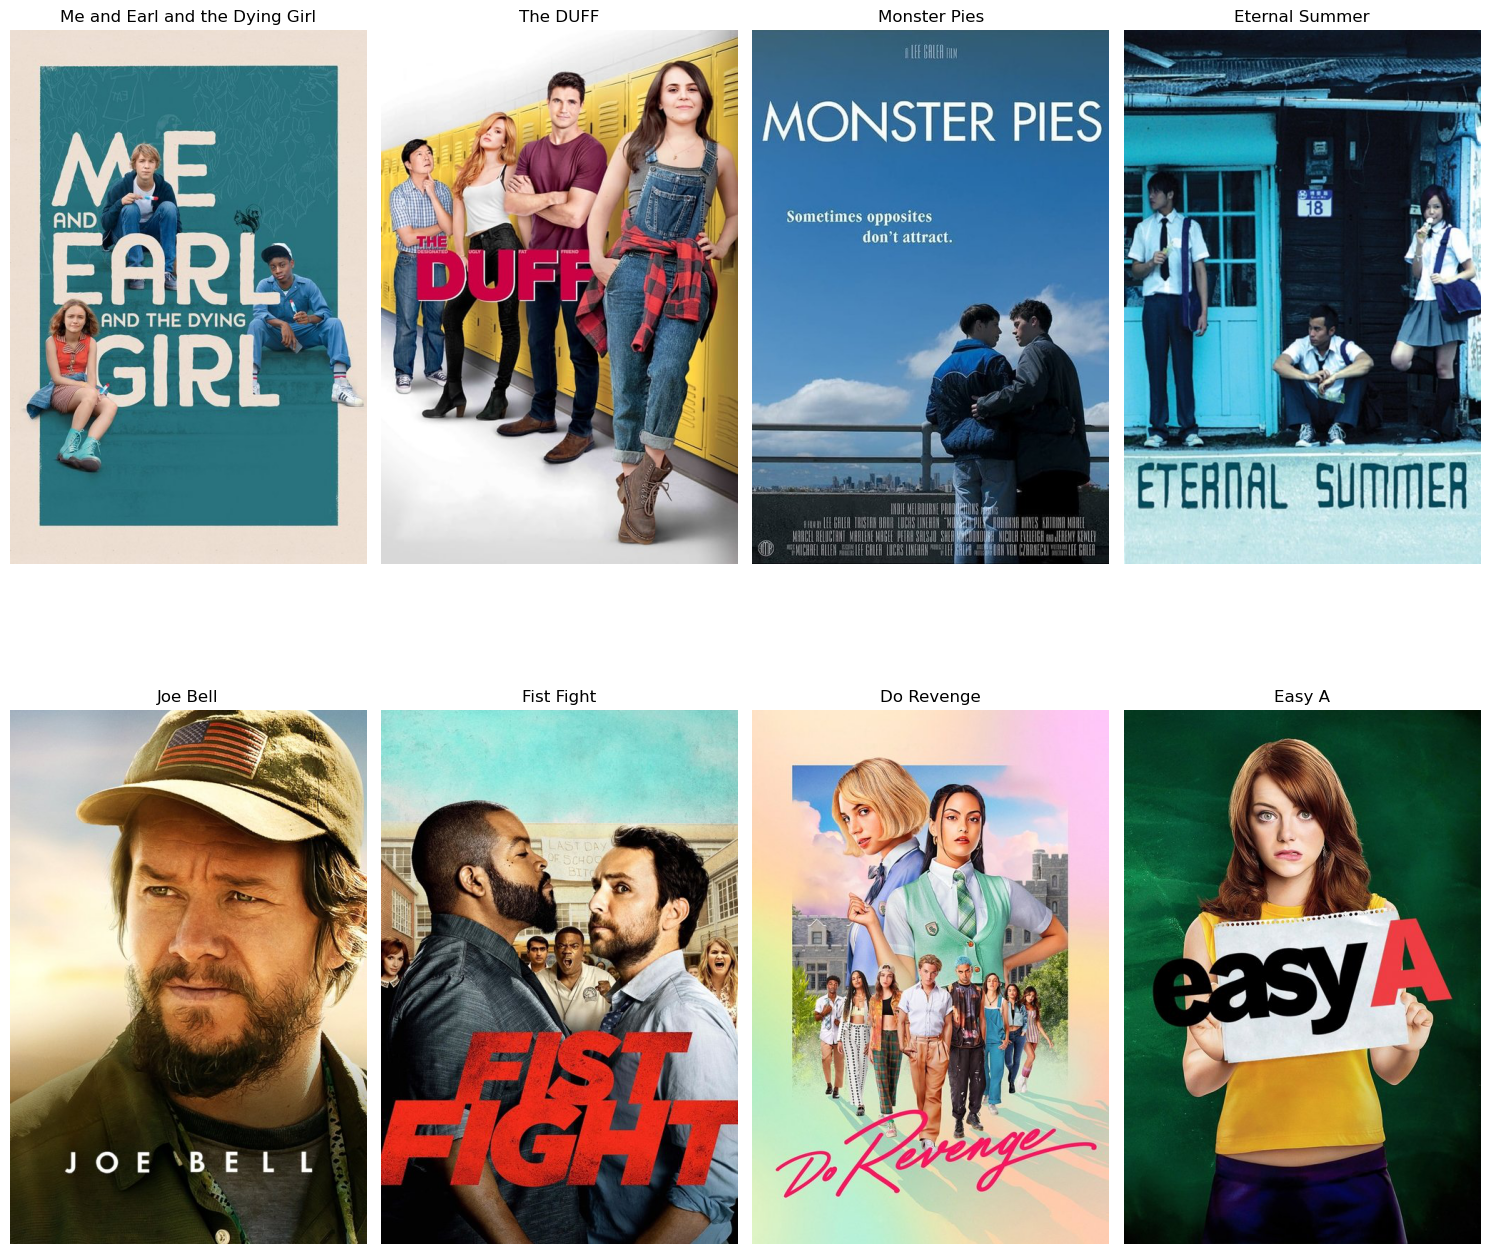

In [109]:
get_recommendations('The Perks of Being a Wallflower')

In [115]:
pickle.dump(df1,open('movie_list.pkl','wb'))
pickle.dump(tfidf_matrix,open('tfidf_matrix.pkl','wb'))

In [117]:
!pip install streamlit

  Obtaining dependency information for streamlit from https://files.pythonhosted.org/packages/eb/17/fc425e1d4d86e31b2aaf0812a2ef2163763a0670d671720c7c36e8679323/streamlit-1.44.1-py3-none-any.whl.metadata
  Using cached streamlit-1.44.1-py3-none-any.whl.metadata (8.9 kB)
  Obtaining dependency information for altair<6,>=4.0 from https://files.pythonhosted.org/packages/aa/f3/0b6ced594e51cc95d8c1fc1640d3623770d01e4969d29c0bd09945fafefa/altair-5.5.0-py3-none-any.whl.metadata
  Using cached altair-5.5.0-py3-none-any.whl.metadata (11 kB)
  Obtaining dependency information for blinker<2,>=1.0.0 from https://files.pythonhosted.org/packages/10/cb/f2ad4230dc2eb1a74edf38f1a38b9b52277f75bef262d8908e60d957e13c/blinker-1.9.0-py3-none-any.whl.metadata
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Obtaining dependency information for cachetools<6,>=4.0 from https://files.pythonhosted.org/packages/72/76/20fa66124dbe6be5cafeb312ece67de6b61dd91a0247d1ea13db4ebb33c2/cachetools-5.5.2-py